In [2]:
pip install pandas matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

●	Simpan data setiap hasil proses dalam bentuk csv / excel ( soal 1-6).
●	Setiap proses ditampilkan juga dalam bentuk visualisasi ( soal 2-6).
1.	Lakukan agregasi data.
2.	Lakukan analisis outliers dan berikan penjelasan serta solusi jika diperlukan.
3.	Lakukan analisis missing value dan berikan penjelasan dan solusi yang diperlukan.
4.	Lakukan analisis imbalance data  dan berikan  penjelasan dan solusi jika diperlukan.
5.	Lakukan analisis korelasi antara variabel dan temukan variabel yang paling berpengaruh. Berikan kesimpulan hasil analisis Anda.
6.	Lakukan analisis data anomali dan berikan penjelasan hasil analisis Anda.


In [6]:
data = pd.read_csv('facial_skin_temperature.csv')
print(data)

      time  facial_skin_temperature
0      0.0                33.849000
1      1.0                33.839667
2      2.0                33.829000
3      3.0                33.817267
4      4.0                33.804742
..     ...                      ...
952  952.0                34.388465
953  953.0                34.327677
954  954.0                34.256426
955  955.0                34.179942
956  956.0                34.100842

[957 rows x 2 columns]


In [7]:
# Agregasi data (mean, min, max, std)
aggregated_data = data['facial_skin_temperature'].agg(['mean', 'min', 'max', 'std']).reset_index()
aggregated_data.columns = ['Metric', 'Value']

# Menyimpan agregasi data ke csv
aggregated_data.to_csv('aggregated_data.csv', index=False)

# Print hasil
print(aggregated_data)

  Metric      Value
0   mean  34.070283
1    min  33.450323
2    max  34.588645
3    std   0.198833


In [22]:
# Load data 
data1 = pd.read_csv('facial_skin_temperature.csv')
data2 = pd.read_csv('heart_rate.csv')

# Menggabungkan data baris
result = pd.concat([data1, data2], ignore_index=True)

# Menggabungkan data kolom
result = pd.concat([data1, data2], axis=1)

# Menampilkan hasil
print(result)

      time  facial_skin_temperature   time  heart_rate
0      0.0                33.849000    0.0  102.000000
1      1.0                33.839667    1.0  101.333333
2      2.0                33.829000    2.0  100.571429
3      3.0                33.817267    3.0   99.200000
4      4.0                33.804742    4.0   98.064516
..     ...                      ...    ...         ...
953  953.0                34.327677  953.0   90.806452
954  954.0                34.256426  954.0   89.354839
955  955.0                34.179942  955.0   88.096774
956  956.0                34.100842  956.0   86.935484
957    NaN                      NaN  957.0   85.870968

[958 rows x 4 columns]


outliers

In [18]:
df = pd.read_csv('facial_skin_temperature.csv')
df = pd.read_csv('heart_rate.csv')
#Fungsi untuk menghitung outlier menggunakan IQR
def count_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((data < lower_bound) | (data > upper_bound)).sum()

# Menghitung outliers di setiap kolom numerik 
outlier_counts = {}
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    outlier_counts[col] = count_outliers_iqr(df[col])

# Mengubah hasil menjadi DataFrame 
outlier_counts_df = pd.DataFrame(list(outlier_counts.items()),
                                 columns=['Column', 'Outlier Count'])

# Menampilkan jumlah outlier dataframenya
outlier_counts_df

,Column,Outlier Count
0,time,0
1,heart_rate,29


In [26]:
# Periksa missing valuenya
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
time          0
heart_rate    0
dtype: int64


In [28]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
# Menampilkan kolom kategorikal
print("Kolom Kategorikal:")
print(categorical_columns)

Kolom Kategorikal:
Index([], dtype='object')


In [31]:
df.isnull().sum()

time          0
heart_rate    0
dtype: int64

   time  heart_rate
0   0.0  102.000000
1   1.0  101.333333
2   2.0  100.571429
3   3.0   99.200000
4   4.0   98.064516
Distribution of target classes:
time
957.0    1
0.0      1
1.0      1
2.0      1
3.0      1
        ..
18.0     1
17.0     1
16.0     1
15.0     1
14.0     1
Name: count, Length: 958, dtype: int64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8436\104384726.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


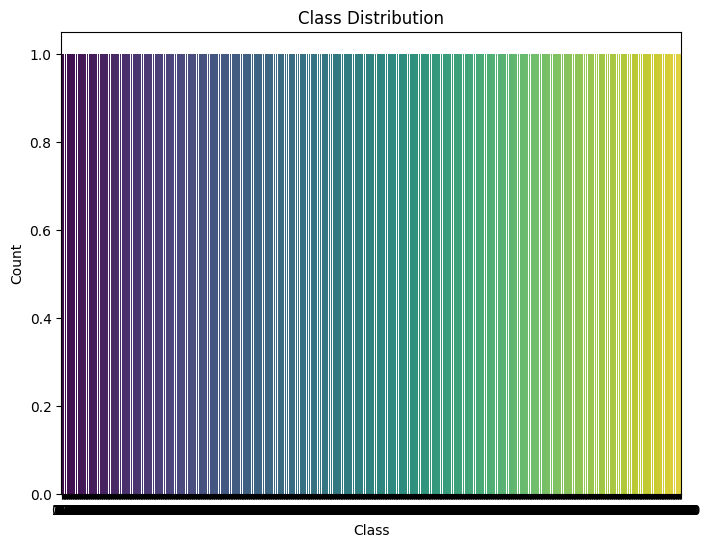

Imbalance Ratio: 1.00


In [36]:
data = pd.read_csv('heart_rate.csv')

# Menampilkan kolom pertama data
print(data.head())
target_column = 'time'
class_counts = data[target_column].value_counts()
# Print variabel distribusi
print("Distribution of target classes:")
print(class_counts)
# plot distribusi untuk menganalisis 
plt.figure(figsize=(8,6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()
# Menghitung rasio
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Imbalance Ratio: {imbalance_ratio:.2f}")
